In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [3]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 89.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 64.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [16]:
import dagshub
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as pp
import seaborn as sns
!pip install scorecardpy --quiet
import scorecardpy as sc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)
from category_encoders.woe import WOEEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.tree import DecisionTreeClassifier
dagshub.init(repo_owner='kgord23', repo_name='ML_hw_02_IEEE-CIS', mlflow=True)
mlflow.set_experiment("Decision_Tree_Training")

Initialized MLflow to track repo "kgord23/ML_hw_02_IEEE-CIS"

Repository kgord23/ML_hw_02_IEEE-CIS initialized!

<Experiment: artifact_location='mlflow-artifacts:/c9cb7b8c9fdb4f4b97d36624d96c66d9', creation_time=1777821540589, experiment_id='1', last_update_time=1777821540589, lifecycle_stage='active', name='Decision_Tree_Training', tags={}, trace_location=None, workspace='default'>

<h1>Data Loading</h1>

In [5]:
train_transaction= pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

In [6]:
train = train_transaction.merge(train_identity, on="TransactionID", how="left")

In [7]:
X=train.drop(columns='isFraud')
Y=train['isFraud']

X_train, X_val, Y_train, Y_val= train_test_split(X,Y, test_size=0.2, random_state=42)
X_train_raw = X_train.copy()
X_val_raw = X_val.copy()


<h1>Cleaning</h1>

In [9]:
class NULLDropperThreshold(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.80):
        self.threshold=threshold
        
    def fit(self, X, y=None):
        missing_frac=X.isna().mean()
        self.cols_to_drop=missing_frac[missing_frac>self.threshold].index.tolist()
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])

In [7]:
missing_percent = X_train.isna().mean()* 100
missing_percent.sort_values(ascending=False)
missing_percent.describe()
missing_frac=X_train.isna().mean()
missing_frac = missing_frac[missing_frac > 0].sort_values(ascending=False)

In [8]:
threshold=0.80
cols_to_drop = missing_frac[missing_frac>threshold].index
X_train=X_train.drop(columns=cols_to_drop)
X_val=X_val.drop(columns=cols_to_drop)

In [9]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype=='object']
num_cols=[col for col in X_train.columns if X_train[col].dtype!='object']

In [10]:
class NULLFiller(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        num_cols=X.select_dtypes(exclude=['object']).columns
        cat_cols=X.select_dtypes(include=['object']).columns
        self.median=X[num_cols].median()
        self.mode=X[cat_cols].mode().iloc[0]
        return self

    def transform (self, X):
        X=X.copy()
        num_cols=X.select_dtypes(exclude=['object']).columns
        cat_cols=X.select_dtypes(include=['object']).columns
        X[num_cols]=X[num_cols].fillna(self.median)
        X[cat_cols]=X[cat_cols].fillna(self.mode)
        return X

In [10]:
median=X_train[num_cols].median()
X_train[num_cols]=X_train[num_cols].fillna(median)
X_val[num_cols]=X_val[num_cols].fillna(median)

mode=X_train[cat_cols].mode().iloc[0]
X_train[cat_cols]=X_train[cat_cols].fillna(mode)
X_val[cat_cols]=X_val[cat_cols].fillna(mode)

In [11]:
class VarianceThreshold(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.01):
        self.threshold=threshold

    def fit(self, X, y=None):
        num_cols = X.select_dtypes(exclude=['object']).columns
        self.selected=VarianceThreshold(threshold=self.threshold)
        self.selected.fit(X[num_cols])
        self.low_var_cols=X[num_cols].columns[~self.selected.get_support()].tolist()
        return self
    def transform(self, X):
        return X.drop(columns=[c for c in self.low_var_cols if c in X.columns])

In [11]:
from sklearn.feature_selection import VarianceThreshold
selected = VarianceThreshold(threshold=0.01)
selected.fit(X_train[num_cols])
num_cols = X_train.select_dtypes(exclude=['object']).columns
low_var_cols=num_cols[~selected.get_support()].tolist()
print(f"low variance columns: {len(low_var_cols)}")
print(low_var_cols)
X_train=X_train.drop(columns=low_var_cols)
X_val=X_val.drop(columns=low_var_cols)


low variance columns: 24
['V1', 'V14', 'V27', 'V28', 'V41', 'V65', 'V68', 'V88', 'V89', 'V107', 'V108', 'V110', 'V111', 'V112', 'V113', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V240', 'V241', 'V305']


In [24]:
with mlflow.start_run(run_name="Decision_Tree_Cleaning"):
    mlflow.log_param("null_threshold", 0.8)
    mlflow.log_param("filling_numeric", "median")
    mlflow.log_param("filling_cat", "mode")
    mlflow.log_param("variance_threshold", 0.01)
    mlflow.log_metric("low_variance_columns", len(low_var_cols))
    mlflow.log_metric("remaining_features", X_train.shape[1])
    mlflow.log_metric("remaining_rows", X_train.shape[0])

🏃 View run Decision_Tree_Cleaning at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/1/runs/89b8d23823d641dab254ba75daabc677
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/1


<h1>Feature Engineering</h1>

In [12]:
class NewColsAdd(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.email_freq=X['P_emaildomain'].value_counts()
        self.card_freqs={}
        for col in ['card1', 'card2', 'addr1']:
            self.card_freqs[col]=X[col].value_counts()
        X_tmp=X.copy()
        X_tmp['card_det']=X_tmp['card1'].astype(str) + '_' + X_tmp['card2'].astype(str) + '_' + X_tmp['addr1'].astype(str)
        self.card_det_freq=X_tmp['card_det'].value_counts()
        return self

    def transform(self, X):
        X=X.copy()
        X['TransactionAmt_log'] = np.log1p(X['TransactionAmt'])
        X['Transaction_hour'] = ((X['TransactionDT'] / 3600) % 24).astype(int)
        X['Transaction_day'] = ((X['TransactionDT'] / (3600 * 24)) % 7).astype(int)
        X['P_emaildomain_freq'] = X['P_emaildomain'].map(self.email_freq)
        X['card_det']=X['card1'].astype(str)+ '_' + X['card2'].astype(str)+'_'+X['addr1'].astype(str)

        for col in ['card1', 'card2', 'addr1']:
            X[col + '_freq'] = X[col].map(self.card_freqs[col])
        X['card_det_freq'] = X['card_det'].map(self.card_det_freq)
        return X

        

In [12]:
X_train['TransactionAmt_log']= np.log1p(X_train['TransactionAmt'])
X_val['TransactionAmt_log']=np.log1p(X_val['TransactionAmt'])

email_freq=X_train['P_emaildomain'].value_counts()
X_train['P_emaildomain_freq'] = X_train['P_emaildomain'].map(email_freq)
X_val['P_emaildomain_freq']=X_val['P_emaildomain'].map(email_freq)


X_train['Transaction_day'] = ((X_train['TransactionDT']/(3600*24))%7).astype(int)
X_train['Transaction_hour'] = ((X_train['TransactionDT']/3600)%24).astype(int)
X_val['Transaction_day'] = ((X_val['TransactionDT']/(3600*24))%7).astype(int)
X_val['Transaction_hour'] = ((X_val['TransactionDT']/3600)%24).astype(int)

X_train['card_det'] = X_train['card1'].astype(str)+'_' + X_train['card2'].astype(str)+'_' + X_train['addr1'].astype(str)
X_val['card_det'] = X_val['card1'].astype(str)+'_' + X_val['card2'].astype(str)+'_' + X_val['addr1'].astype(str)
for col in ['card1', 'card2', 'addr1', 'card_det']:
    card_freq=X_train[col].value_counts()
    X_train[col+'_freq']=X_train[col].map(card_freq)
    X_val[col+'_freq']=X_val[col].map(card_freq)

/tmp/ipykernel_58/4102201427.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['TransactionAmt_log']= np.log1p(X_train['TransactionAmt'])
/tmp/ipykernel_58/4102201427.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_val['TransactionAmt_log']=np.log1p(X_val['TransactionAmt'])
/tmp/ipykernel_58/4102201427.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) 

In [13]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"amount_of_cat_cols: {len(cat_cols)}")
print(f"cols: {cat_cols}")


amount_of_cat_cols: 27
cols: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'card_det']


In [13]:
class Encoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ohe_cols=['card4', 'card6', 'DeviceType', 'M1', 'M2', 'M3', 
                        'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'ProductCD']
        self.woe_cols=['P_emaildomain', 'R_emaildomain', 'id_12', 'id_15', 
                        'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 
                        'id_37', 'id_38', 'DeviceInfo', 'card_det']
    def fit(self, X, y=None):
        self.woe_cols_pr=[c for c in self.woe_cols if c in X.columns]
        self.ohe_cols_pr=[c for c in self.ohe_cols if c in X.columns]

        self.woe=WOEEncoder(cols=self.woe_cols_pr)
        self.woe.fit(X[self.woe_cols_pr],y)

        X_tmp = pd.get_dummies(X, columns=self.ohe_cols_pr)
        self.ohe_feature_names = [c for c in X_tmp.columns 
                                    if any(c.startswith(col+'_') 
                                    for col in self.ohe_cols_pr)]
        return self

    def transform(self, X):
        X=X.copy()
        X[self.woe_cols_pr]=self.woe.transform(X[self.woe_cols_pr])
        X=pd.get_dummies(X, columns=self.ohe_cols_pr)
        X=X.fillna(0)
        return X
        

In [14]:
from category_encoders import WOEEncoder
ohe_cols = ['card4', 'card6', 'DeviceType', 'M1', 'M2', 'M3', 
            'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'ProductCD']

woe_cols = ['P_emaildomain', 'R_emaildomain', 'id_12', 'id_15', 
            'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 
            'id_37', 'id_38', 'DeviceInfo', 'card_det']

woe=WOEEncoder(cols=woe_cols)
X_train[woe_cols]=woe.fit_transform(X_train[woe_cols], Y_train)
X_val[woe_cols]=woe.transform(X_val[woe_cols])
print(f"after WOE : {X_train.shape[1]}")


X_train=pd.get_dummies(X_train, columns=ohe_cols)
X_val = pd.get_dummies(X_val, columns = ohe_cols)
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
print(f"afte OHE: {X_train.shape[1]}")

after WOE : 344
afte OHE: 365


In [30]:
with mlflow.start_run(run_name="Decision_Tree_Feature_Engineering"):
    mlflow.log_metric("total_features", X_train.shape[1])
    mlflow.log_param("ohe_cols", ", ".join(ohe_cols))
    mlflow.log_param("woe_cols", ", ".join(woe_cols))

🏃 View run Decision_Tree_Feature_Engineering at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/1/runs/f119b7e511364c0fa4ef0c1b8bc15067
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/1


<h1>Feature Selection</h1>

In [14]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.85):
        self.threshold=threshold
    def fit(self, X, y=None):
        corr_matrix = X.corr().abs()
        corr_with_target = X.copy()
        corr_with_target['isFraud'] = y.values
        corr_with_target = corr_with_target.corr()['isFraud'].drop('isFraud')
        self.to_drop=set()
        for i in range (len(corr_matrix.columns)):
            for j in range(i +1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i,j])>  self.threshold:
                    col_i = corr_matrix.columns[i]
                    col_j = corr_matrix.columns[j]
                    if abs (corr_with_target[col_i])<abs(corr_with_target[col_j]):
                        self.to_drop.add(col_i)
                    else:
                        self.to_drop.add(col_j)
        return self
        

    def transform(self, X):
        return X.drop(columns=[c for c in self.to_drop if c in X.columns])


    

In [15]:
corr_matrix = X_train.corr().abs()
corr_with_target = X_train.copy()
corr_with_target['isFraud'] = Y_train.values
corr_with_target = corr_with_target.corr()['isFraud'].drop('isFraud')
threshold=0.85
to_drop=set()
for i in range (len(corr_matrix.columns)):
    for j in range(i +1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j])>threshold:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            if abs (corr_with_target[col_i])<abs(corr_with_target[col_j]):
                to_drop.add(col_i)
            else:
                to_drop.add(col_j)
print(f"to_delete: {len(to_drop)}")
print(to_drop)

X_train = X_train.drop(columns=list(to_drop))
X_val=X_val.drop(columns=list(to_drop))
print(f"left cols: {X_train.shape[1]}")

to_delete: 190
{'V213', 'V73', 'M8_T', 'id_17', 'M9_F', 'V176', 'V44', 'C1', 'V304', 'V132', 'V31', 'V61', 'V70', 'D2', 'V87', 'V255', 'V288', 'V82', 'DeviceType_mobile', 'V42', 'V30', 'V4', 'C10', 'V207', 'V22', 'V39', 'V180', 'V91', 'V133', 'V58', 'V233', 'V172', 'M7_T', 'V203', 'V43', 'V36', 'ProductCD_C', 'V267', 'V217', 'card6_debit', 'M2_F', 'V19', 'V106', 'V194', 'V34', 'V246', 'V317', 'V11', 'V299', 'V80', 'V269', 'V72', 'V313', 'V21', 'V300', 'V270', 'V71', 'V261', 'V224', 'M3_T', 'V126', 'V186', 'V212', 'V96', 'V128', 'V101', 'V64', 'V104', 'V251', 'V136', 'V319', 'M5_F', 'V316', 'V79', 'M6_T', 'V191', 'V264', 'V308', 'V97', 'V183', 'V242', 'V90', 'V265', 'V105', 'V206', 'V215', 'V92', 'V238', 'V273', 'V49', 'V135', 'V74', 'M4_M2', 'V237', 'V285', 'V178', 'V230', 'V279', 'V243', 'V318', 'V190', 'V33', 'V59', 'V196', 'V266', 'C12', 'V85', 'V179', 'V218', 'C14', 'V293', 'V298', 'V100', 'V129', 'V168', 'V227', 'V32', 'V15', 'V69', 'V60', 'V127', 'V276', 'V259', 'V245', 'V63', 'C

In [32]:
!pip install scorecardpy --quiet
import scorecardpy as sc
iv_v=sc.iv(X_train.join(Y_train), y='isFraud')
threshold_iv=0.02
weak_iv=iv_v[iv_v['info_value']<threshold_iv]['variable'].tolist()

print(f"weak_iv_cols: {len(weak_iv)}")
X_train=X_train.drop(columns=weak_iv)
X_val=X_val.drop(columns=weak_iv)
print(f"left_cols: {X_train.shape[1]}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


/usr/local/lib/python3.12/dist-packages/scorecardpy/info_value.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(goodbad) \
/usr/local/lib/python3.12/dist-packages/scorecardpy/info_value.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(goodbad) \
/usr/local/lib/python3.12/dist-packages/scorecardpy/info_value.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behav

weak_iv_cols: 31
left_cols: 144


/usr/local/lib/python3.12/dist-packages/scorecardpy/info_value.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(goodbad) \


In [33]:
with mlflow.start_run(run_name="Decision_Tree_Feature_Selection"):
    mlflow.log_param("corr_threshold", 0.85)
    mlflow.log_param("IV_threshold", 0.02 )
    mlflow.log_metric("left columns",X_train.shape[1])

🏃 View run Decision_Tree_Feature_Selection at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/1/runs/9bbeb44c23b842d1aaea10fee60fb73e
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/1


<h1>Training</h1>

Train ROC-AUC:      0.9097
Validation ROC-AUC: 0.8876
differance:            0.0221
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113866
           1       0.79      0.42      0.55      4242

    accuracy                           0.98    118108
   macro avg       0.89      0.71      0.77    118108
weighted avg       0.97      0.98      0.97    118108



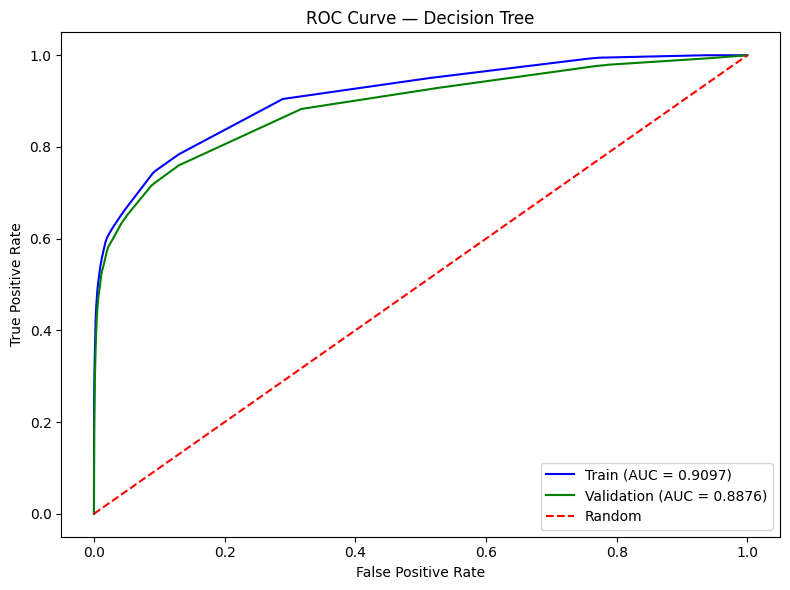

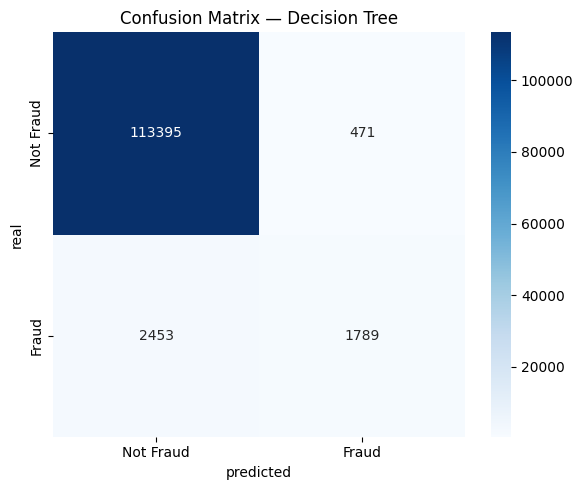

<Figure size 1000x800 with 0 Axes>

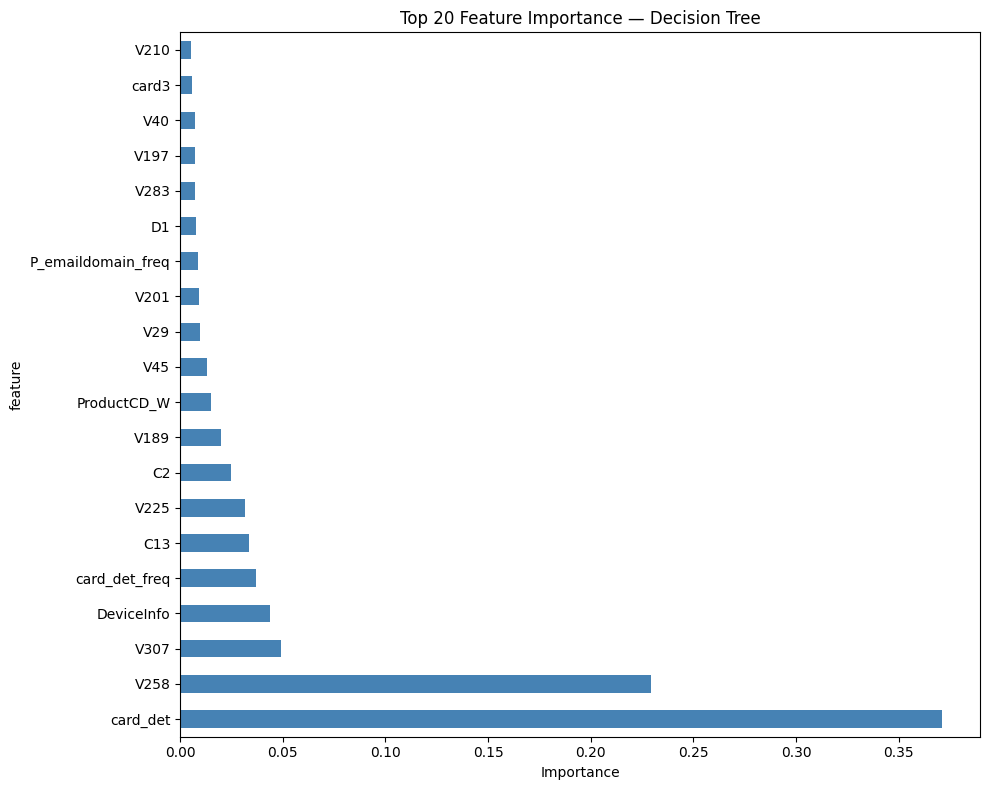

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
decision_tree=DecisionTreeClassifier(max_depth=10, min_samples_split=80, min_samples_leaf=60, random_state=42)
decision_tree.fit(X_train,Y_train)

Y_pred_proba_train=decision_tree.predict_proba(X_train)[:,1]
Y_pred_proba_val=decision_tree.predict_proba(X_val)[:,1]
Y_pred_val=decision_tree.predict(X_val)

roc_auc_train=roc_auc_score(Y_train, Y_pred_proba_train)
roc_auc_val=roc_auc_score(Y_val, Y_pred_proba_val)
print(f"Train ROC-AUC:      {roc_auc_train:.4f}")
print(f"Validation ROC-AUC: {roc_auc_val:.4f}")
print(f"differance:            {roc_auc_train - roc_auc_val:.4f}")
print(classification_report(Y_val, Y_pred_val))

fpr_train, tpr_train, _ = roc_curve(Y_train, Y_pred_proba_train)
fpr_val, tpr_val, _ = roc_curve(Y_val, Y_pred_proba_val)

pp.figure(figsize=(8, 6))
pp.plot(fpr_train, tpr_train, color='blue', label=f'Train (AUC = {roc_auc_train:.4f})')
pp.plot(fpr_val, tpr_val, color='green', label=f'Validation (AUC = {roc_auc_val:.4f})')
pp.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random')
pp.title('ROC Curve — Decision Tree')
pp.xlabel('False Positive Rate')
pp.ylabel('True Positive Rate')
pp.legend()
pp.tight_layout()
pp.savefig('dt_roc_curve.png')
pp.show()

cm = confusion_matrix(Y_val, Y_pred_val)
pp.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
pp.title('Confusion Matrix — Decision Tree')
pp.ylabel('real')
pp.xlabel('predicted')
pp.tight_layout()
pp.savefig('dt_confusion_matrix.png')
pp.show()

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': decision_tree.feature_importances_
}).sort_values('importance', ascending=False)

pp.figure(figsize=(10, 8))
importance_df.head(20).plot(
    x='feature', y='importance',
    kind='barh', figsize=(10, 8),
    color='steelblue', legend=False
)
pp.title('Top 20 Feature Importance — Decision Tree')
pp.xlabel('Importance')
pp.tight_layout()
pp.savefig('dt_feature_importance.png')
pp.show()

In [39]:
with mlflow.start_run(run_name="Decision_Tree_Training"):
    mlflow.log_param("null_threshold", 0.80)
    mlflow.log_param("corr_threshold", 0.85)
    #mlflow.log_param("IV_threshold", 0.02)
    mlflow.set_tag("description", "did not make IV filter ")
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("min_samples_split", 80)
    mlflow.log_param("min_samples_leaf", 60)
    mlflow.log_metric("roc_auc_train", roc_auc_train)
    mlflow.log_metric("roc_auc_val", roc_auc_val)
    mlflow.log_artifact("dt_roc_curve.png")
    mlflow.log_artifact("dt_confusion_matrix.png")
    mlflow.log_artifact("dt_feature_importance.png")

🏃 View run Decision_Tree_Training at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/1/runs/cfd3d4b42d074e3f888e6f92609d889a
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/1


In [17]:
from sklearn.pipeline import Pipeline
full_pipeline=Pipeline([
    ('null_dropper', NULLDropperThreshold(threshold=0.80)),
    ('filler', NULLFiller()),
    ('new_cols_add',NewColsAdd()),
    ('encoder', Encoder()),
    ('correlation', CorrelationFilter(threshold=0.85)),
    ('model', DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=80,
        min_samples_leaf=60,
        random_state=42
    ))                  
])

In [18]:
full_pipeline.fit(X_train_raw,Y_train)
y_pred_proba = full_pipeline.predict_proba(X_val_raw)[:, 1]
y_train_proba = full_pipeline.predict_proba(X_train_raw)[:, 1]

roc_auc_val = roc_auc_score(Y_val, y_pred_proba)
roc_auc_train = roc_auc_score(Y_train, y_train_proba)

print(f"Train ROC-AUC:      {roc_auc_train:.4f}")
print(f"Validation ROC-AUC: {roc_auc_val:.4f}")
print(f"diff:            {roc_auc_train - roc_auc_val:.4f}")

Train ROC-AUC:      0.9097
Validation ROC-AUC: 0.8882
diff:            0.0215


In [20]:
with mlflow.start_run(run_name="Decision_Tree_Pipeline_Final"):
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("min_samples_split", 80)
    mlflow.log_param("min_samples_leaf", 60)
    mlflow.log_param("correlation_threshold", 0.85)
    mlflow.log_metric("roc_auc_train", roc_auc_train)
    mlflow.log_metric("roc_auc_val", roc_auc_val)
    mlflow.sklearn.log_model(full_pipeline, "Decision_Tree_Pipeline")
    

2026/05/04 14:30:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 14:30:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Decision_Tree_Pipeline_Final at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/1/runs/5d00826fe7be421fb634b91cfd81aae6
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/1
